# Transformada discreta de Fourier (DFT)

In [148]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Implementação da transformada

Dado um sinal representado por um array $f$. A DFT do sinal é calculada através da equação:

\begin{equation}
F_m = \sum_{n=0}^{M-1}f_ne^{-2\pi imn/M}
\end{equation}
onde $M$ é o tamanho do array, $n$ e $m$ são os índices dos arrays $f$ e $F$ (array resultante), e $f_n$ indica o elemento de índice $n$ do array $f$. 

In [149]:
def dft(fn):
    """Transformada discreta de Fourier"""
    M = len(fn)
    Fm = np.zeros(M, dtype=complex)
    # Para cada frequência
    for m in range(M):
        # Para cada valor do sinal (instante de tempo, posição espacial, etc)
        for n in range(M):
            Fm[m] += fn[n]*np.exp(-1j*2.*np.pi*m*n/M)

    return Fm

DFT de um sinal coseno

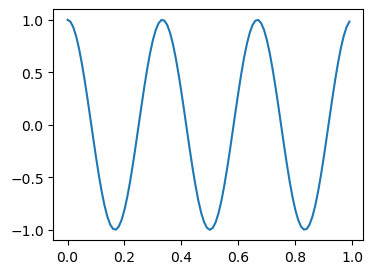

In [150]:
frequency = 3.
x = np.linspace(0, 1, 100, endpoint=False)
y = np.cos(2*np.pi*frequency*x)
plt.plot(x, y)

In [151]:
# Calcula e imprime a transformada.
Fy = dft(y)
print(Fy)

[-3.99680289e-15+0.00000000e+00j  4.32986980e-15+5.89805982e-16j
  4.44089210e-16+4.91273688e-15j  5.00000000e+01+2.77555756e-17j
  1.33226763e-15+1.24900090e-15j -1.02140518e-14+3.49720253e-15j
 -5.55111512e-16-3.55271368e-15j  3.21964677e-15+8.10462808e-15j
 -3.99680289e-15-6.66133815e-16j -9.21485110e-15-1.43218770e-14j
 -1.64313008e-14-3.49720253e-14j -2.55351296e-14-5.88418203e-15j
  1.47659662e-14-3.21964677e-15j  1.93178806e-14+9.43689571e-15j
 -2.98649994e-14-2.93098879e-14j -1.62092562e-14-2.06501483e-14j
  1.64313008e-14-4.09672296e-14j  2.77555756e-15-1.16573418e-14j
 -1.36557432e-14+3.77475828e-15j  4.99600361e-15+1.12132525e-14j
  5.87307980e-14-1.03250741e-14j -6.16173779e-15-3.40838469e-14j
 -2.75057754e-14-2.32036612e-14j -4.42562653e-14-6.88338275e-15j
  2.26207941e-14-5.17363929e-14j  1.29209599e-14-3.44169138e-15j
  1.54043445e-15+1.24344979e-14j -3.84831056e-14+3.88578059e-15j
 -4.11060075e-14-2.84217094e-14j  3.09197112e-14+8.77076189e-15j
 -6.28941343e-14-1.754152

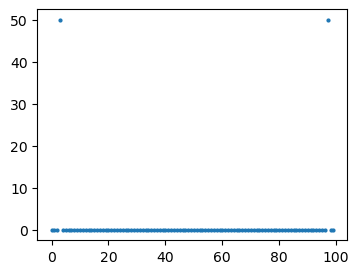

In [152]:
# plota a transformada. Note que os valores de Fy são complexos, 
# então para plotar precisamos calcular o valor absoluto
plt.plot(np.abs(Fy), "o", ms=2)

Note que Fy possui apenas as amplitudes das frequências do sinal. Isto é, ainda não conhecemos a frequência associada a cada amplitude. Tais frequências serão calculadas abaixo.

## 2. Calculando as frequências

O array Fy calculado acima possui as magnitudes da transformada de Fourier, mas não tem qualquer informação sobre as frequências associadas a cada magnitude. Para calcular as frequências, utilizamos o teorema de Nyquist, que revela que a maior frequência do sinal que podemos representar é dada por

\begin{equation}
f_{max}=\frac{1}{2\Delta x}
\end{equation}
onde $\Delta x$ é o intervalo de amostragem da função (por exemplo, um sinal amostrado a cada 0.1 segundo).
Como o domínio da frequência da transformada de fourier tem a parte negativa, o intervalo de frequências da transformada começa em $-f_{max}$ e termina em $f_{max}$. Portanto, o intervalo total a ser utilizado é $2f_{max}$. As frequências são então divididas em $M$ valores, onde $M$ é o tamanho do array do sinal de entrada. Ou seja, a frequência possui incrementos dados por $\Delta f=2f_{max}/M$.

In [153]:
delta_x = x[1]-x[0]     # Intervalo de amostragem
f_max = 1/(2*delta_x)    # Máxima frequência a ser representada (teorema de Nyquist)
print(f"Frequência máxima representável: {f_max:.2f} Hz")

Frequência máxima representável: 50.00 Hz


In [154]:
from scipy.fft import fftfreq

freqs = fftfreq(len(x), delta_x)
freqs

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49., -50., -49., -48., -47., -46.,
       -45., -44., -43., -42., -41., -40., -39., -38., -37., -36., -35.,
       -34., -33., -32., -31., -30., -29., -28., -27., -26., -25., -24.,
       -23., -22., -21., -20., -19., -18., -17., -16., -15., -14., -13.,
       -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,
        -1.])

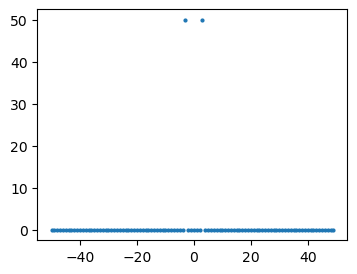

In [155]:
plt.plot(freqs, np.abs(Fy), "o", ms=2)

In [141]:
print(freqs[:5])
print(np.abs(Fy[:5]))

[0. 1. 2. 3. 4.]
[3.99680289e-15 4.36985624e-15 4.93276788e-15 5.00000000e+01
 1.82618189e-15]


Outro detalhe é que a saída da DFT possui uma ordenação peculiar das frequências. Supondo que as frequências que queremos representar são dadas por [-3, -2, -1, 0, 1, 2, 3], o resultado da DFT é um array onde cada elemento é relativo ás seguintes frequências: [0, 1, 2, 3, -3, -2, -1]. Se o tamanho do sinal for par, as frequências são [0, 1, 2, -3, -2, -1].

Para "corrigir" a posição das frequências, precisamos utilizar a função fftshift.

In [157]:
from scipy.fft import fftshift

# A função fftshift reorganiza os valores do array de forma que as frequências fiquem 
# em uma ordem mais intuitiva:
# [0, f1, f2, .., fmax, -fmax, .., -f2, -f1] -> [-fmax, .., -f2, -f1, 0, f1, f2, .., fmax]

freqs = fftshift(freqs)
Fy = fftshift(Fy)

print(freqs)

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]


## 3. Cálculo prático da DFT

Para sinais reais (não complexos), podemos sempre utilizar uma versão da transformada de Fourier otimizada para sinais reais. Essa versão retorna somente a parte real da transformada.

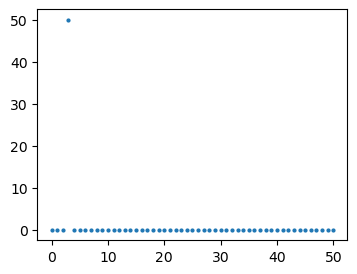

In [158]:
from scipy.fft import rfft, rfftfreq

Fy = rfft(y)
freqs = rfftfreq(len(x), x[1]-x[0])
plt.plot(freqs, np.abs(Fy), "o", ms=2)

Para recuperarmos o sinal original, basta aplicarmos a transformada inversa.

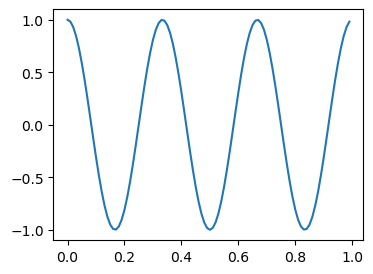

In [159]:
from scipy.fft import irfft

y_rec = irfft(Fy)
plt.plot(x, y_rec)